# Validation Pipeline Sketch V5
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
# import multiprocessing
# import random

# from dataclasses import dataclass, field
# from joblib import Parallel, delayed
from pathlib import Path
# from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Type

from tqdm.notebook import tqdm

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

# from sklearn.base import ClusterMixin, TransformerMixin
# from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
# from sklearn.metrics import adjusted_rand_score, pairwise_distances
# from sklearn.model_selection import ParameterGrid
# from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

import umap

import matplotlib.pyplot as plt

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
def plot_dim_reduced_clustering(
    X: np.ndarray, 
    clusters: np.ndarray, 
    method: str = 'PCA', 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    ax: plt.Axes = None, 
    show: bool = True
) -> plt.Axes:
    """
    Plot a 2D embedding of the data colored by cluster assignments.

    :param X: the input data matrix to be reduced and plotted (n_samples, n_features)
    :param clusters: cluster labels for each sample (n_samples,)
    :param method: dimensionality reduction method to use; either 'PCA' or 'tSNE'
    :param ax: a matplotlib axes object to be plotted on
    :param show: controls whether to call plt.show()

    :return: plt.Axes if show = False, otherwise displays a scatter plot with the samples colored by cluster assignment
    """
    # dimensionality reduction
    if method == 'PCA':
        X_red = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    elif method == 'tSNE':
        X_red = TSNE(
            n_components=2,
            random_state=RANDOM_SEED,
            perplexity=perplexity
        ).fit_transform(X)
    elif method == 'UMAP':
        X_red = umap.UMAP(
            n_components=2, 
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            random_state=RANDOM_SEED  # throws a warning
        ).fit_transform(X)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")

    # build discrete colormap for clusters
    unique_clusters = np.unique(clusters)
    base_cmap = plt.get_cmap('Set1', len(unique_clusters))
    color_dict = {lab: base_cmap(i) for i, lab in enumerate(unique_clusters)}

    # plot points
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    point_colors = [color_dict[lab] for lab in clusters]
    ax.scatter(X_red[:, 0], X_red[:, 1], c=point_colors, s=10, alpha=0.8)

    # handle legend
    for lab in unique_clusters:
        ax.scatter([], [], c=[color_dict[lab]], label=f"cluster {lab}", s=50, alpha=0.8)
        
    ax.legend(loc='lower right', frameon=False)

    # titles & axis labels
    if method == 'PCA':
        ax.set(
            title="PCA of Data Set",
            xlabel="PCA 1",
            ylabel="PCA 2"
        )
    elif method == 'tSNE':
        ax.set(
            title="t-SNE of Data Set",
            xlabel="t-SNE 1",
            ylabel="t-SNE 2"
        )
    else:
        ax.set(
            title="UMAP of Data Set",
            xlabel="UMAP 1",
            ylabel="UMAP 2"
        )

    if show:
        plt.tight_layout()
        plt.show()
    else:
        return ax

### 0.2 Data Import:

PANCAN dataset:

In [48]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

labels = pd.read_csv(labels_fp, header=None, skiprows=1)

sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)
numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

print("X shape:", X.shape, " |  y shape:", y.shape)

found 20531 numeric cols out of 20532
X shape: (801, 20531)  |  y shape: (801,)


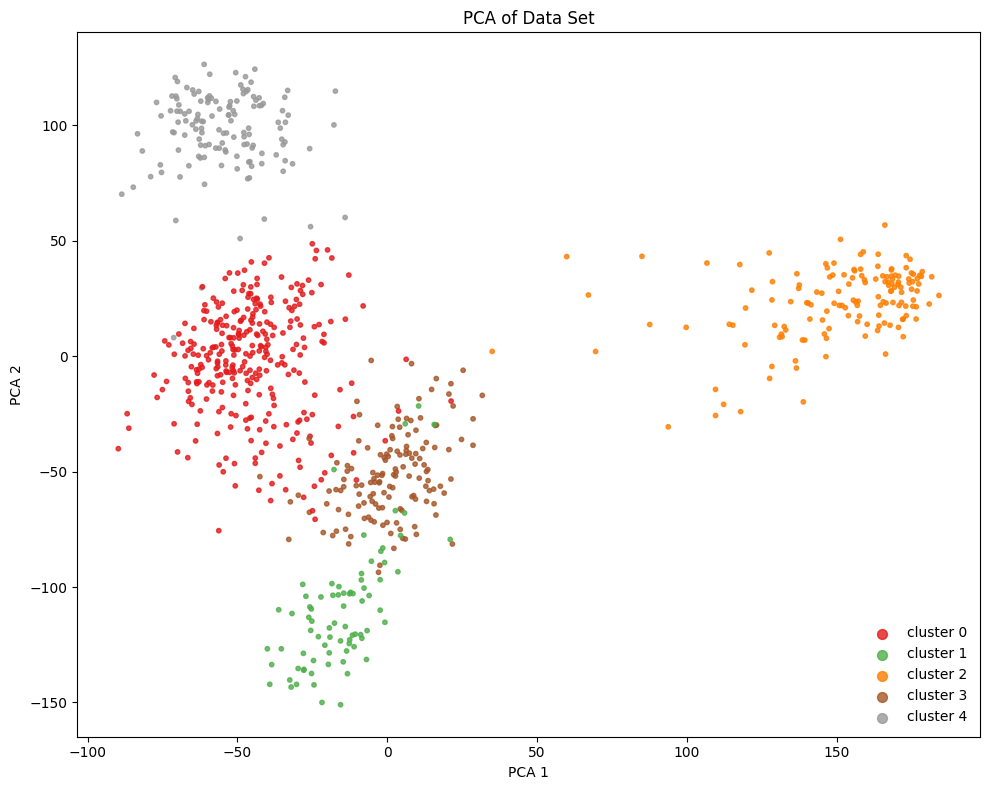

In [26]:
plot_dim_reduced_clustering(X, y, method='PCA')

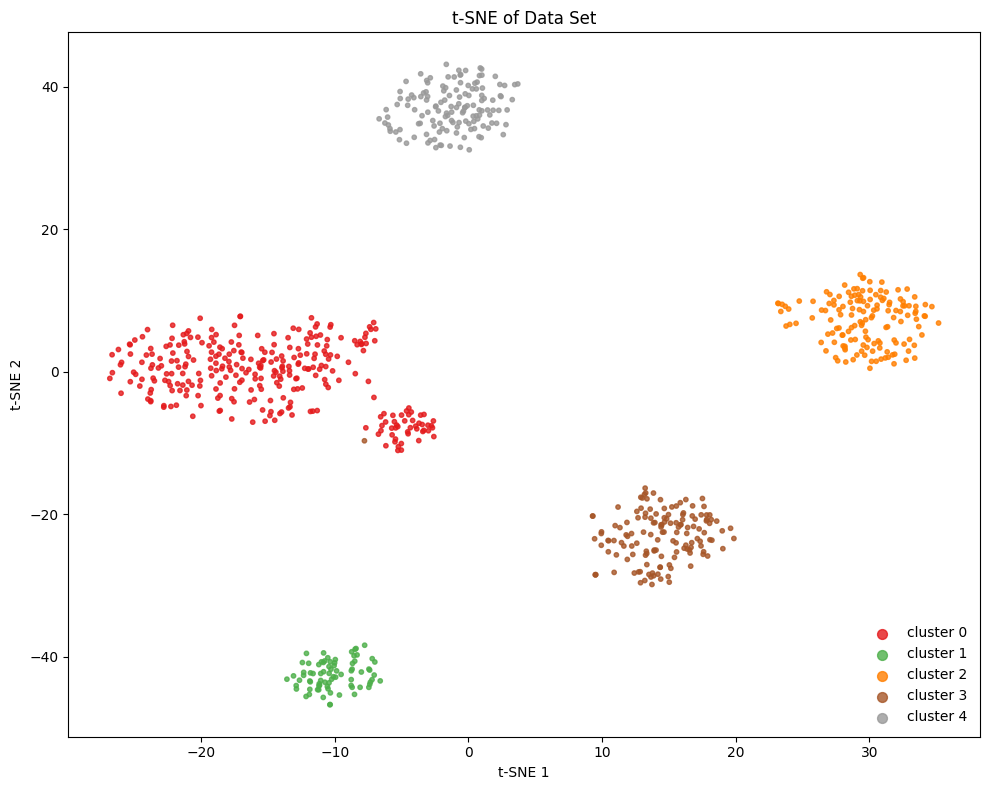

In [27]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


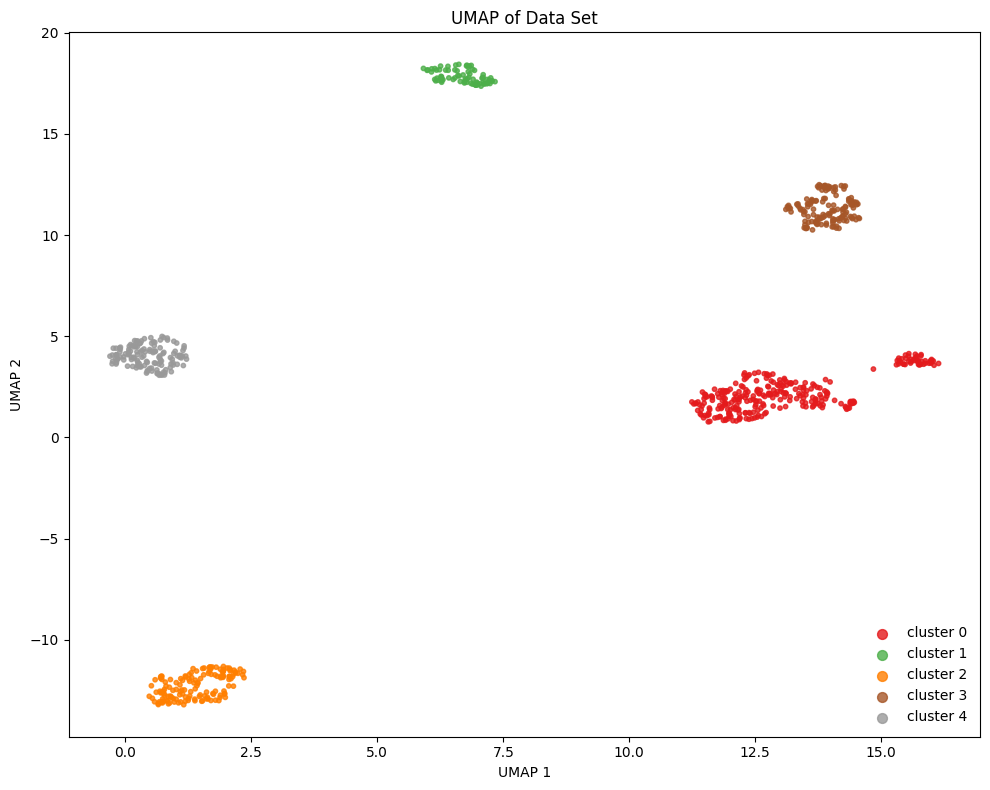

In [28]:
plot_dim_reduced_clustering(X, y, method='UMAP')

IRIS dataset:

In [9]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print("X shape:", X.shape, " |  y shape:", y.shape)

X shape: (150, 4)  |  y shape: (150,)


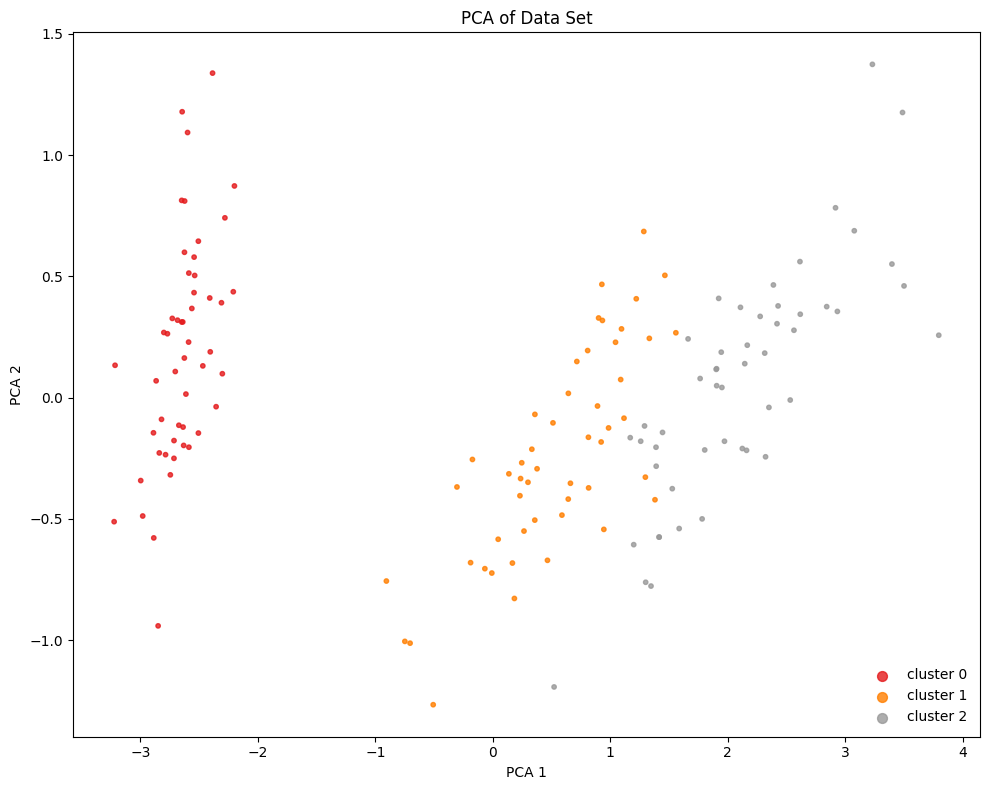

In [30]:
plot_dim_reduced_clustering(X, y, method='PCA')

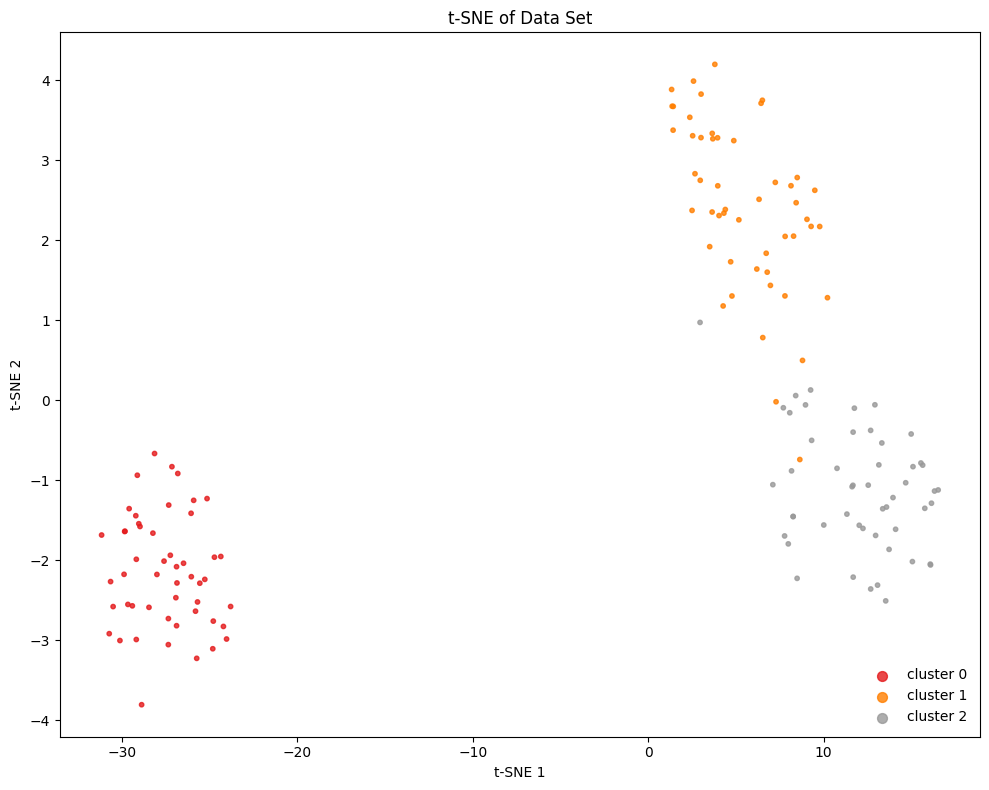

In [31]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


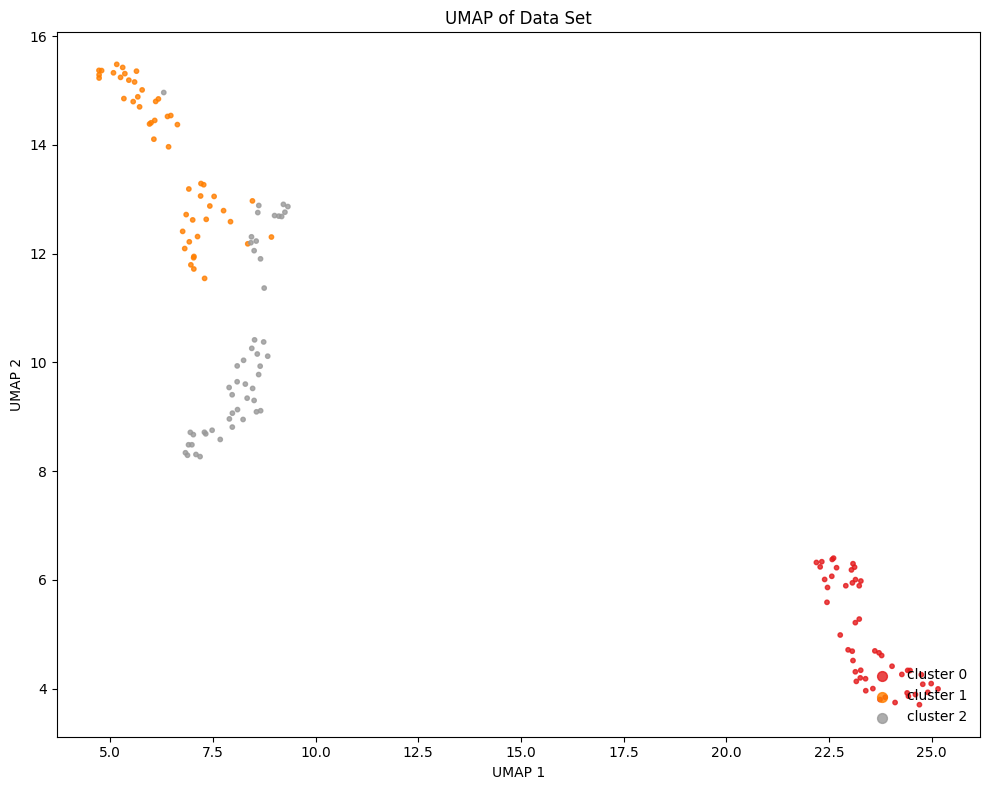

In [32]:
plot_dim_reduced_clustering(X, y, method='UMAP')

DARMANIS:

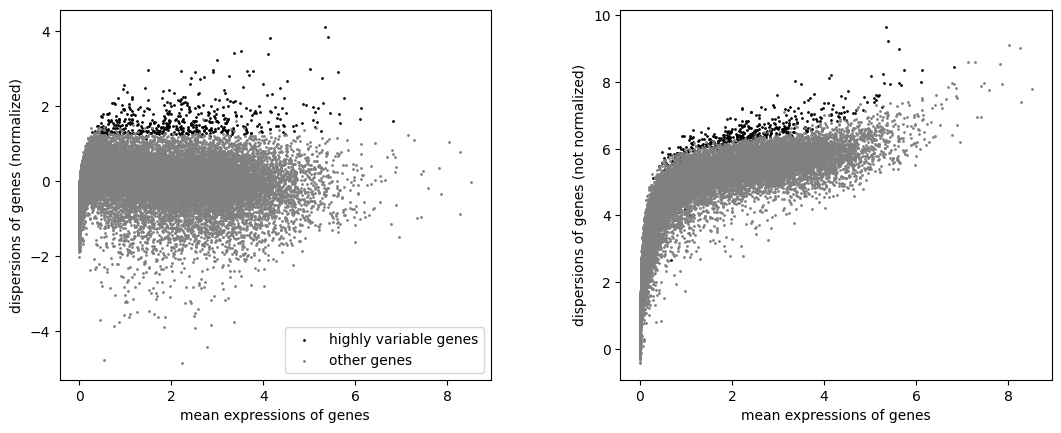

X shape: (3589, 500)


In [4]:
adata = ad.read_h5ad('data/DARMANIS/darmanis_fromraw.h5ad')

sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat')
sc.pl.highly_variable_genes(adata)

adata_hvg = adata[:, adata.var['highly_variable']]
X = adata_hvg.X

print("X shape:", X.shape)

In [ ]:
plot_dim_reduced_clustering(X, y, method='PCA')

In [ ]:
plot_dim_reduced_clustering(X, y, method='tSNE')

In [ ]:
plot_dim_reduced_clustering(X, y, method='UMAP')

---

## 1. Cluster Analysis with Resampling for Validation and Exploration (CARVE) Algorithm:

In [8]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


carve/utils.py:

In [9]:
import numpy as np
from sklearn.base import ClusterMixin
from typing import Any, Type

def subsample_indices(n_samples: int, ratio: float = 0.6, seed: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param seed: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(seed)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

def clustering_pipeline(
    X: np.ndarray,
    est_cls: Type[ClusterMixin],
    **params: Any
) -> np.ndarray:
    """
    Fit estimator on X and return labels.

    :param X: Data array, shape (n_samples, n_features).
    :param est_cls: Clustering estimator class.
    :param params: Hyperparameters for estimator.
    
    :return: Array of labels, shape (n_samples,).
    """
    estimator = est_cls(**params)

    if hasattr(estimator, "fit_predict"):
        return estimator.fit_predict(X)
    estimator.fit(X)
    return getattr(estimator, "labels_")

def wrangle_pipeline_df(pipeline_records):
    rows = []
    for record in pipeline_records:
        params = record['params']
        k = params['n_clusters']
        
        for r in record['results']:
            ari_s, ari_g, *_, norm_p, dr_p, norm_name, dr_name = r
            
            if norm_name != 'FunctionTransformer':
                norm_label = norm_name
            else:
                func = norm_p.get('func', None)
                norm_label = func.__name__ if func is not None else 'identity'
            
            if dr_name != 'FunctionTransformer':
                dr_label = dr_name
            else:
                func = dr_p.get('func', None)
                dr_label = func.__name__ if func is not None else 'identity'
                
            rows.append({
                'n_clusters': k, 
                'norm__func': norm_label,
                'dr__method': dr_label, 
                'ari_stability': ari_s, 
                'ari_generalizability': ari_g 
            })
        
    dfp = pd.DataFrame(rows)
    
    return (
        dfp
        .groupby(['norm__func', 'dr__method', 'n_clusters'], as_index=False)
        .mean()
    )

carve/preprocessing.py

In [10]:
from typing import Any, Callable, Dict, List, Tuple
import random
import numpy as np
from sklearn.base import TransformerMixin
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
import umap

PipelineSpec = Tuple[Pipeline, Dict[str, Any], Dict[str, Any]]

def default_norm_options() -> List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]:
    """
    Generate default normalization options.
    
    :return: norm_options
    """
    norm_options = [
        (FunctionTransformer, {}),
        (StandardScaler, {}),
        (FunctionTransformer, {'func': [np.log1p]}),
    ]

    return norm_options

def default_dr_options(
    X: np.ndarray, 
    rho: float = 0.6
) -> List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]:
    """
    Generate default dimensionality-reduction options.

    :param X: Input data array.
    :param rho: Subsampling ratio to determine max DR dims.
    
    :return: dr_options
    """
    n_samples, p = X.shape
    min_n = int(round(n_samples * (1 - rho))) - 1

    dr_options = [
        (FunctionTransformer, {}),
        (PCA, {'n_components': list(range(2, min(min_n, p) + 1))}),
        (TSNE, {'n_components': [2, 3], 'perplexity': list(range(5, min(min_n, 51)))}),
        (umap.UMAP, {'n_components': list(range(2, min(min_n, p) + 1)), 
                     'n_neighbors': list(range(5, 51)), 'min_dist': [0.1]}),
    ]

    return dr_options

def draw_random_pipeline(
    norm_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    dr_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    seed: int = 0
) -> PipelineSpec:
    """
    randomly choose one normalization+DR combo and random hyperparameters.
    """
    rnd = random.Random(seed)
        
    norm_cls, norm_grid = rnd.choice(norm_options)
    dr_cls, dr_grid = rnd.choice(dr_options)
    
    norm_params = {k: rnd.choice(v) for k, v in norm_grid.items()}
    dr_params = {k: rnd.choice(v) for k, v in dr_grid.items()}
    
    norm = norm_cls(**norm_params)
    dr = dr_cls(**dr_params)
    
    pipeline = Pipeline([('norm', norm), ('dr', dr)])
    return pipeline, norm_params, dr_params

carve/metrics.py

In [11]:
import numpy as np
from scipy import sparse
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from typing import List, Tuple

IndexLabels = Tuple[np.ndarray, np.ndarray]  # (indices, labels)
PredLabels = Tuple[np.ndarray, np.ndarray, np.ndarray]  # (idx, true, pred)

def build_consensus_matrix(
    n: int,
    runs: List[IndexLabels]
) -> sparse.csr_matrix:
    """
    runs: list of (idx, labels) from B bootstraps
    """
    co = sparse.csr_matrix((n, n), dtype=float)
    counts = sparse.csr_matrix((n, n), dtype=float)
    
    for idx, labels in runs:
        u = sparse.csr_matrix((np.ones_like(idx), (idx, np.zeros_like(idx))), shape=(n, 1))
        counts += u.dot(u.T)
        uniq, inv = np.unique(labels, return_inverse=True)
        L = sparse.csr_matrix((np.ones_like(idx), (idx, inv)), shape=(n, uniq.size))
        co += L.dot(L.T)
        
    counts.data = 1.0 / counts.data
    consensus = co.multiply(counts).toarray()
    
    dists = squareform(1.0 - consensus, checks=False)
    Z = linkage(dists, method='average')
    order = leaves_list(Z)
    
    C_ord = consensus[order][:, order]
    return sparse.csr_matrix(C_ord)

def build_misclassification_array(
    n: int,
    runs: List[PredLabels]
) -> np.ndarray:
    """
    runs: list of (idx, true_labels, pred_labels)
    """
    correct = np.zeros(n, int)
    total = np.zeros(n, int)
    
    for idx, true, pred in runs:
        corr = (true == pred)
        np.add.at(correct, idx, corr.astype(int))
        np.add.at(total, idx, 1)
        
    mis = np.ones(n, float)
    valid = total > 0
    mis[valid] = 1.0 - (correct[valid] / total[valid])
    return mis

carve/plotting.py

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_results(
    validator,
    measure: str = 'overall'
) -> None:
    """
    plot ari vs. n_clusters for each clustering method + hyperparams,
    and include an overall average performance and indicators for optimal k and best method per k.

    :param method_df: dataframe with columns
        ['estimator', hyperparam cols..., 'n_clusters',
         'ari_stability', 'ari_generalizability', 'ari_overall']
    :param measure: one of 'stability', 'generalizability', or 'overall'
    """
    method_df = validator.method_df
    
    # select column, titles, ylabel
    if measure == 'stability':
        col = 'ari_stability'
        ylabel = 'stability (ARI)'
        title = 'stability per clustering configuration'
    elif measure == 'generalizability':
        col = 'ari_generalizability'
        ylabel = 'generalizability (ARI)'
        title = 'generalizability per clustering configuration'
    elif measure == 'overall':
        col = 'ari_overall'
        ylabel = 'overall (mean) ARI'
        title = 'overall ARI per clustering configuration'
    else:
        raise ValueError(f"invalid measure: {measure}")

    fig, ax = plt.subplots(figsize=(10, 8))

    # compute overall average across all methods
    avg_series = method_df.groupby('n_clusters')[col].mean()
    ax.plot(
        avg_series.index,
        avg_series.values,
        marker='D',
        linestyle='--',
        label='overall average'
    )

    # draw vertical line at optimal k
    optimal_k = int(avg_series.idxmax())
    ax.axvline(
        optimal_k,
        linestyle=':',
        linewidth=2,
        label=f'optimal overall at k={optimal_k}'
    )

    # determine best method at optimal_k
    subset_k = method_df[method_df['n_clusters'] == optimal_k]
    best_idx_k = subset_k[col].idxmax()
    best_row_k = method_df.loc[best_idx_k]
    # build best label string
    exclude = {'estimator', 'n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall'}
    param_cols = [c for c in best_row_k.index if c not in exclude]
    label_parts = []
    for pc in param_cols:
        val = best_row_k[pc]
        if pd.notna(val):
            label_parts.append(f"{pc}={val}")
    base_label = best_row_k['estimator'].lower()
    best_label = base_label + (f" ({', '.join(label_parts)})" if label_parts else '') + ' *'

    # plot each method
    for est in method_df['estimator'].unique():
        df_est = method_df[method_df['estimator'] == est]

        # identify hyperparam columns
        exclude = {'estimator', 'n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall'}
        param_cols = [c for c in df_est.columns if c not in exclude]

        # group by hyperparams
        if param_cols:
            groups = df_est.groupby(param_cols, dropna=False)
        else:
            groups = [(None, df_est)]

        for _, grp in groups:
            grp = grp.sort_values('n_clusters')

            # build label
            label_parts = []
            for pc in param_cols:
                val = grp.iloc[0][pc]
                if pd.notna(val):
                    label_parts.append(f"{pc}={val}")
            label = est.lower() + (f" ({', '.join(label_parts)})" if label_parts else '')
            is_best = (label + ' *' == best_label)
            plot_label = best_label if is_best else label

            ax.plot(
                grp['n_clusters'],
                grp[col],
                marker='o',
                label=plot_label
            )

            # circle best method at optimal_k
            if is_best:
                best_y = grp[grp['n_clusters'] == optimal_k][col].values[0]
                ax.scatter(
                    [optimal_k], [best_y],
                    facecolors='none',
                    edgecolors='black',
                    s=200,
                    linewidths=2
                )

    ax.set_xlabel('n_clusters')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    
def plot_consensus_matrix(
    validator,
    measure: str = 'overall', 
    k: int = None
) -> None:
    """
    Plot consensus matrix for the best clustering at a chosen k or automatically selected k.

    :param method_df: DataFrame with columns ['n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall', ...]
    :param cons_mats: list of consensus matrices corresponding to rows in method_df
    :param measure: one of 'stability', 'generalizability', or 'overall'
    :param k: optional number of clusters; if provided, use this k and skip overall averaging
    """
    method_df = validator.method_df
    cons_mats = validator.cons_mats
    
    # select metric column
    if measure == 'stability':
        col = 'ari_stability'
    elif measure == 'generalizability':
        col = 'ari_generalizability'
    elif measure == 'overall':
        col = 'ari_overall'
    else:
        raise ValueError(f"unknown measure {measure!r}")

    # determine optimal k if not provided
    if k is None:
        avg_per_k = method_df.groupby('n_clusters')[col].mean()
        optimal_k = int(avg_per_k.idxmax())
    else:
        optimal_k = k
        if optimal_k not in method_df['n_clusters'].unique():
            raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

    # pick best method
    subset_k = method_df[method_df['n_clusters'] == optimal_k]
    best_idx = subset_k[col].idxmax()
    best_row = method_df.loc[best_idx]

    # get consensus matrix
    C = cons_mats[best_idx].toarray()

    # build title
    fixed = {'estimator', 'n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall'}
    params = {
        key: best_row[key]
        for key in best_row.index
        if key not in fixed and pd.notnull(best_row[key])
    }
    param_str = ', '.join(f"{key} = {value}" for key, value in params.items())
    title = f"{best_row['estimator']} | k = {optimal_k}" + (f", {param_str}" if param_str else "")

    # plot
    plt.figure(figsize=(10, 8))
    plt.imshow(C, aspect='auto', interpolation='none')
    plt.colorbar(label='consensus')
    plt.title(title)
    plt.xlabel('samples (ordered)')
    plt.ylabel('samples (ordered)')
    plt.show()

def plot_stability_clustering(
    validator, 
    measure: str = 'overall',
    k: int = None
) -> None:
    """
    side-by-side plots:
      1) first two pca components, points colored by optimal clustering:
         • dot size ∝ 1 / sample-variance(row in consensus matrix)
         • alpha (opacity) per cluster ∝ cluster-level mean variance
      2) boxplot of per-sample variances by cluster

    :param validator: a fitted ClusteringValidator instance
    :param measure: one of "stability", "generalizability", or "overall"
    :param k: optional number of clusters; if provided, use this k
    """
    # map measure to column
    valid = {
        "stability": "ari_stability",
        "generalizability": "ari_generalizability",
        "overall": "ari_overall",
    }
    if measure not in valid:
        raise ValueError(f"invalid measure {measure!r}, must be one of {list(valid)}")
    col = valid[measure]

    df = validator.method_df

    # pick k: either user-specified or best by average across all models
    if k is None:
        avg_per_k = df.groupby('n_clusters')[col].mean()
        optimal_k = int(avg_per_k.idxmax())
    else:
        optimal_k = k
        if optimal_k not in df['n_clusters'].unique():
            raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

    # now pick the single best model at that k
    subset_k = df[df['n_clusters'] == optimal_k]
    best_idx = subset_k[col].idxmax()

    # get labels for the best model on full X
    _, labels = validator.get_optimal_model(
        measure=measure, 
        return_labels=True,
        k=optimal_k
    )

    X = validator.X
    C = validator.cons_mats[best_idx].toarray()

    # compute per-sample variance of consensus
    sample_vars = np.var(C, axis=1)
    mn_var, mx_var = sample_vars.min(), sample_vars.max()

    # size ∝ 1/variance
    inv = 1.0 / (sample_vars + 1e-8)
    if np.isclose(mx_var, mn_var):
        sizes = np.full_like(sample_vars, 80.0)
        alpha_map = {c: 0.7 for c in np.unique(labels)}
    else:
        sizes = 20 + (inv - inv.min()) / (inv.max() - inv.min()) * 180
        # per-cluster mean variance → opacity
        clu_var = {c: sample_vars[labels == c].mean() for c in np.unique(labels)}
        v = np.array(list(clu_var.values()))
        mn, mx = v.min(), v.max()
        alpha_map = {
            c: 0.3 + (clu_var[c] - mn) / (mx - mn + 1e-8) * (1.0 - 0.3)
            for c in clu_var
        }

    # PCA scatter
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    for c in np.unique(labels):
        mask = labels == c
        ax1.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=sizes[mask],
            alpha=alpha_map[c],
            label=f"cluster {c}"
        )
    params = {key: subset_k.loc[best_idx][key]
              for key in subset_k.columns
              if key not in {'estimator','n_clusters','ari_stability','ari_generalizability','ari_overall'} and pd.notnull(subset_k.loc[best_idx][key])}
    param_str = ', '.join(f"{key} = {value}" for key, value in params.items())
    ax1.set_title(f"{subset_k.loc[best_idx]['estimator']} | k = {optimal_k}" + (f", {param_str}" if param_str else ""))
    ax1.set_title(f"pca (2 comps) & clusters (k={optimal_k}, {measure})")
    ax1.set_xlabel("pc1")
    ax1.set_ylabel("pc2")
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Boxplot of per-sample variances by cluster
    data = [sample_vars[labels == c] for c in np.unique(labels)]
    ax2.boxplot(data, tick_labels=[str(c) for c in np.unique(labels)])
    ax2.set_title("per-sample variance by cluster")
    ax2.set_xlabel("cluster")
    ax2.set_ylabel("sample variance")

    plt.tight_layout()
    plt.show()
    
def plot_generalizability_clustering(
    validator,
    measure: str = 'generalizability',
    k: int = None
) -> None:
    """
    side-by-side plots for clustering based on generalizability measure,
    but using misclassification rate for visualization:
      - PCA scatter: dot size ∝ sample accuracy (1 - misclassification rate)
      - cluster opacity ∝ aggregated misclassification rate (lower mis → more opaque)
      - boxplot: per-sample misclassification rate by cluster

    :param measure: one of 'stability', 'generalizability', or 'overall' for selecting k
    :param k: if provided, override k selection
    """
    # map measure to column for k selection
    valid = {
        'stability': 'ari_stability',
        'generalizability': 'ari_generalizability',
        'overall': 'ari_overall'
    }
    
    if measure not in valid:
        raise ValueError(f"invalid measure {measure!r}, must be one of {list(valid)}")
    col = valid[measure]

    df = validator.method_df
    mis_arrs = validator.mis_arrs

    # get optimal k
    if k is None:
        avg_per_k = df.groupby('n_clusters')[col].mean()
        optimal_k = int(avg_per_k.idxmax())
    else:
        optimal_k = k
        if optimal_k not in df['n_clusters'].unique():
            raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

    subset_k = df[df['n_clusters'] == optimal_k]
    best_idx = subset_k[col].idxmax()

    # get labels for best model
    _, labels = validator.get_optimal_model(
        measure=measure, return_labels=True, k=optimal_k
    )

    X = validator.X
    mis = mis_arrs[best_idx]

    # compute sizes
    accuracy = 1.0 - mis
    if np.isclose(accuracy.max(), accuracy.min()):
        sizes = np.full_like(accuracy, 80.0)
    else:
        sizes = 20 + (accuracy - accuracy.min()) / (accuracy.max() - accuracy.min()) * 180

    # compute opacity
    cluster_mis = {c: mis[labels == c].mean() for c in np.unique(labels)}
    vals = np.array(list(cluster_mis.values()))
    alpha_map = {
        c: 0.3 + (1 - ((v - vals.min()) / (vals.max() - vals.min() + 1e-8))) * 0.7
        for c, v in cluster_mis.items()
    }

    # PCA scatter
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    for c in np.unique(labels):
        mask = labels == c
        ax1.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=sizes[mask], alpha=alpha_map[c], label=f"cluster {c}"
        )

    params = {key: subset_k.loc[best_idx][key]
              for key in subset_k.columns
              if key not in {'estimator','n_clusters','ari_stability','ari_generalizability','ari_overall'}
                 and pd.notnull(subset_k.loc[best_idx][key])}
    param_str = ', '.join(f"{key} = {value}" for key, value in params.items())
    ax1.set_title(
        f"{subset_k.loc[best_idx]['estimator']} | k = {optimal_k}" +
        (f", {param_str}" if param_str else "")
    )
    ax1.set_xlabel("pc1")
    ax1.set_ylabel("pc2")
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # boxplot
    data = [mis[labels == c] for c in np.unique(labels)]
    ax2.boxplot(data, tick_labels=[str(c) for c in np.unique(labels)])
    ax2.set_title("per-sample misclassification rate by cluster")
    ax2.set_xlabel("cluster")
    ax2.set_ylabel("misclassification rate")

    plt.tight_layout()
    plt.show()

carve/validation.py

In [13]:
import numpy as np

from joblib import Parallel, delayed
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.model_selection import ParameterGrid
from typing import Any, Dict, List, Optional, Tuple, Type

# from .preprocessing import draw_random_pipeline
# from .consensus import build_consensus_matrix, build_misclassification_array
# possible other imports

ClusterResult = Tuple[
    float, float,  # ARI stability, ARI generalizability
    np.ndarray, np.ndarray, np.ndarray,  # labels_1, labels_test, labels_pred
    np.ndarray, np.ndarray,  # idx_test, idx_train
    Dict[str, Any], Dict[str, Any],  # norm_params, dr_params
    str, str  # norm_name, dr_name
]

def validation_iter(
    X: np.ndarray,
    est_class: Type,
    params: Dict[str, Any],
    rho: float,
    B: int,
    seed: int,
    norm_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    dr_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    random_preproc: bool = True
) -> ClusterResult:
    """ single bootstrap + ARI eval """
    n_samples = X.shape[0]
    P_1_idx, P_test_idx = subsample_indices(n_samples, rho, seed)
    P_2_idx, _ = subsample_indices(n_samples, rho, seed + B)
    
    if random_preproc:
        pipeline, norm_p, dr_p = draw_random_pipeline(
            norm_options=norm_options, 
            dr_options=dr_options,
            seed=seed
        )
        norm_name = pipeline.named_steps['norm'].__class__.__name__
        dr_name = pipeline.named_steps['dr'].__class__.__name__
    else:
        pipeline = Pipeline([('id', FunctionTransformer(lambda x: x))])
        norm_p = dr_p = {}
        norm_name = dr_name = 'Identity'

    X_1 = pipeline.fit_transform(X[P_1_idx])
    X_test = pipeline.fit_transform(X[P_test_idx])
    X_2 = pipeline.fit_transform(X[P_2_idx])
    
    # clustering 
    labels_1 = clustering_pipeline(X_1, est_class, **params)
    labels_test = clustering_pipeline(X_test, est_class, **params)
    labels_2 = clustering_pipeline(X_2, est_class, **params)
    
    # model-explorer ARI
    _, i_1, i_2 = np.intersect1d(P_1_idx, P_2_idx, return_indices=True)
    ari_stab = (adjusted_rand_score(labels_1[i_1], labels_2[i_2]) + normalized_mutual_info_score(labels_1[i_1], labels_2[i_2])) / 2
    
    # predictive ARI
    rf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=X.shape[1],
        max_features=int(np.sqrt(X.shape[1])),
        random_state=seed, 
        n_jobs=-1
    )
    rf.fit(X_1, labels_1)
    labels_pred = rf.predict(X_test)
    ari_pred = (adjusted_rand_score(labels_test, labels_pred) + normalized_mutual_info_score(labels_test, labels_pred)) / 2
    
    return [
        ari_stab, ari_pred, 
        labels_1, labels_test, labels_pred, 
        P_1_idx, P_test_idx, 
        norm_p, dr_p, 
        norm_name, dr_name
    ]
    
def run_validation(
    X: np.ndarray,
    model_grids: List[Tuple[Type, Dict[str, List[Any]]]],
    B: int,
    rho: float,
    norm_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    dr_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]], 
    random_preproc: bool = False, 
    num_cores: int = 1
) -> Tuple[
    List[Dict[str, Any]],  # method_records
    pd.DataFrame,  # pipeline_df
    List[sparse.csr_matrix],  # cons_mats
    List[np.ndarray],  # mis_arrs    
]:
    """
    loops over all (estimator, param) and B seeds in parallel.
    returns:
      - records  (n_methods × metrics)
      - consensus matrices list
      - misclassification arrays list
    """
    method_records = []
    pipeline_records = []
    cons_mats = []
    mis_arrs = []
    
    n = X.shape[0]
    
    total_configs = sum(len(list(ParameterGrid(g))) for _, g in model_grids)
    with tqdm(total=total_configs, desc="Grid configs") as pbar:
        for est_class, grid in model_grids:
            for params in ParameterGrid(grid):
                worker = delayed(validation_iter)
                
                results = Parallel(n_jobs=num_cores)(
                    worker(
                        X=X, 
                        est_class=est_class, 
                        params=params, 
                        rho=rho, 
                        B=B, 
                        seed=b, 
                        norm_options=norm_options, 
                        dr_options=dr_options,
                        random_preproc=random_preproc
                    ) 
                    for b in range(B)
                )
                
                aris_stab = [r[0] for r in results]
                aris_pred = [r[1] for r in results]
                
                cons_mats.append(build_consensus_matrix(n=n, runs=[(r[5], r[2]) for r in results]))  # r[5]: P_1_idx, r[2]: labels_1
                mis_arrs.append(build_misclassification_array(n=n, runs=[(r[6], r[3], r[4]) for r in results]))  # r[6]: P_test_idx, r[3]: labels_test, # r[4]: labels_pred
                
                method_records.append({
                    'estimator': est_class.__name__,
                    **params,
                    'ari_stability': np.mean(aris_stab),
                    'ari_generalizability': np.mean(aris_pred),
                })
                
                if random_preproc:
                    pipeline_records.append({
                        'estimator': est_class.__name__, 
                        'params': params, 
                        'results': results
                    })
                
                pbar.update(1)
                
    return method_records, pipeline_records, cons_mats, mis_arrs

carve/validator.py

In [14]:
import multiprocessing
import numpy as np

from dataclasses import dataclass, field
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from typing import Any, Dict, List, Optional, Tuple, Type

# from .validation import run_validation
# from .plotting import plot_method_metrics, plot_consensus_matrices
# possible other imports

def default_model_grids(
    X: np.ndarray, 
    K: int = 10
) -> List[Tuple[Type[ClusterMixin], Dict[str, List[Any]]]]:
    """
    Generate default clustering estimator grids based on data X.

    :param X: Input data array of shape (n_samples, n_features).
    :param K: Maximum number of clusters to consider.
    
    :return: List of (EstimatorClass, param_grid) tuples.
    """
    D2 = pairwise_distances(X, metric='sqeuclidean')
    median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
    gamma0 = 1.0 / (2.0 * median_d2)
    
    return [
        (KMeans, {'n_clusters': list(range(2, K + 1))}),
        (AgglomerativeClustering, {
            'n_clusters': list(range(2, K + 1)),
            'linkage': ['ward', 'complete', 'average', 'single']
        }),
        (SpectralClustering, {
            'n_clusters': list(range(2, K + 1)),
            'gamma': list(np.logspace(np.log10(gamma0) - 1, np.log10(gamma0) + 1, num=4))
        })
    ]

@dataclass
class ClusteringValidator:
    X: np.ndarray
    K: int = 10
    B: int = 20
    rho: float = 0.6
    
    model_grids: List[Tuple[Type, Dict[str, List[Any]]]] = field(default_factory=list)
    norm_options: Optional[List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]] = None
    dr_options: Optional[List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]] = None
    
    num_cores: int = field(default_factory=lambda: max(1, multiprocessing.cpu_count() - 1))
    
    def __post_init__(self):
        if hasattr(self.X, 'values'):
            self.X = self.X.values

        if not self.model_grids:
            self.model_grids = default_model_grids(self.X, self.K)
        if not self.norm_options:
            self.norm_options = default_norm_options()
        if not self.dr_options:
            self.dr_options = default_dr_options(self.X, self.rho)
    
    def fit(self, random_preproc: bool = False):
        """
        run the full grid search.
        """
        method_records, pipeline_records, self.cons_mats, self.mis_arrs = run_validation(
            X=self.X,
            model_grids=self.model_grids,
            B=self.B,
            rho=self.rho,
            norm_options=self.norm_options, 
            dr_options=self.dr_options, 
            random_preproc=random_preproc,
            num_cores=self.num_cores
        )
        
        self.method_df = pd.DataFrame.from_records(method_records)
        self.method_df['ari_overall'] = (
            self.method_df[['ari_stability', 'ari_generalizability']]
            .mean(axis=1)
        )
        
        if random_preproc:
            self.pipeline_df = wrangle_pipeline_df(pipeline_records)
        else:
            self.pipeline_df = None
        
        return self.method_df
    
    def get_optimal_model(
        self, 
        measure: str = 'overall', 
        return_labels: bool = False, 
        k: int = None
    ) -> Tuple[ClusterMixin, Optional[np.ndarray]]:
        """
        Returns the best clustering estimator fitted with optimal parameters based on the given measure,
        but selects k by averaging the chosen metric across all models, then picks the best model at that k.
        Optionally returns cluster labels on the full dataset.

        :param measure: Criterion to optimize, one of "stability", "generalizability", or "overall".
        :param return_labels: Whether to return cluster labels on the full dataset.
        :param k: optional number of clusters; if provided, use this k and skip overall averaging

        :return: Tuple containing the clustering object and optionally the cluster labels.
        """
        if self.method_df is None:
            raise RuntimeError("You must run `fit()` before getting the optimal clustering.")

        valid_measures = {
            "stability": "ari_stability", 
            "generalizability": "ari_generalizability", 
            "overall": "ari_overall"
        }
        if measure not in valid_measures:
            raise ValueError(f"Invalid measure: {measure!r}. Must be one of {list(valid_measures)}.")

        col = valid_measures[measure]

        # determine optimal k if not provided
        if k is None:
            avg_per_k = self.method_df.groupby('n_clusters')[col].mean()
            optimal_k = int(avg_per_k.idxmax())
        else:
            optimal_k = k
            if optimal_k not in self.method_df['n_clusters'].unique():
                raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

        # within that k, pick best model
        subset_k = self.method_df[self.method_df['n_clusters'] == optimal_k]
        best_idx = subset_k[col].idxmax()
        best_row = self.method_df.loc[best_idx]

        # reconstruct estimator
        est_name = best_row['estimator']
        est_class = next(cls for cls, _ in self.model_grids if cls.__name__ == est_name)

        exclude_cols = {"estimator", "ari_stability", "ari_generalizability", "ari_overall"}
        params = {
            k: best_row[k]
            for k in best_row.index
            if k not in exclude_cols and pd.notnull(best_row[k])
        }

        estimator = est_class(**params)

        if return_labels:
            if hasattr(estimator, "fit_predict"):
                labels = estimator.fit_predict(self.X)
            else:
                estimator.fit(self.X)
                labels = getattr(estimator, "labels_")
            return estimator, labels
        else:
            return estimator, None

---

## 2. Examplary Usage:

In [15]:
validator = ClusteringValidator(X, K=15)
results = validator.fit()

Grid configs:   0%|          | 0/126 [00:00<?, ?it/s]

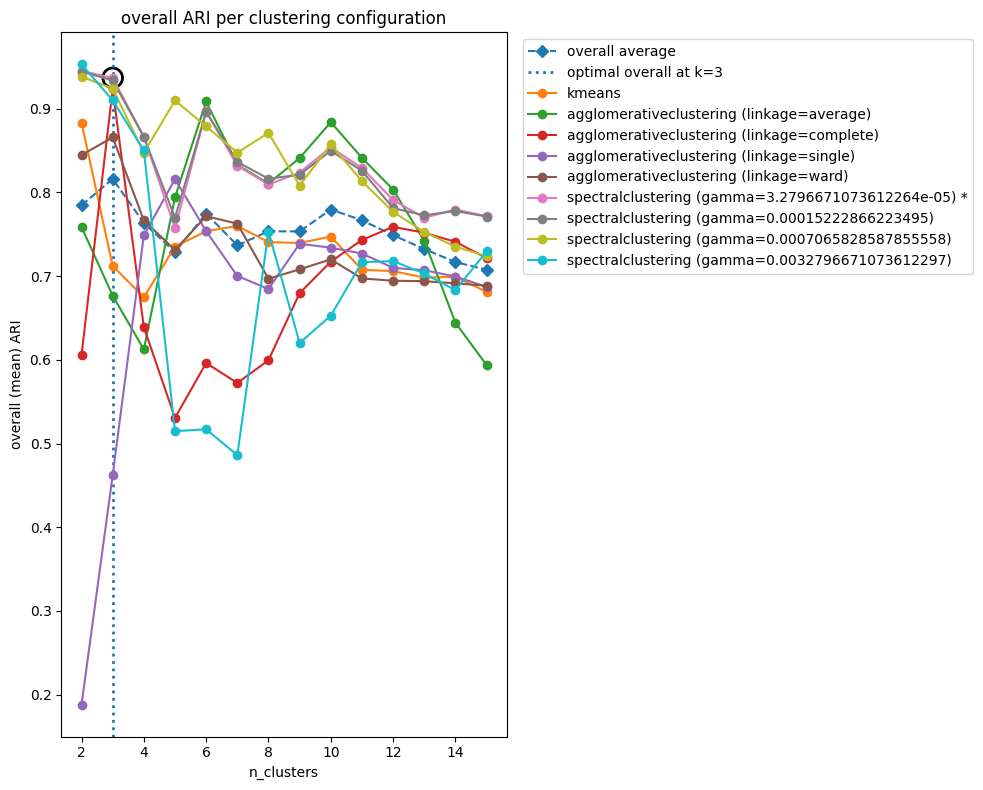

In [26]:
plot_results(validator, measure='overall')

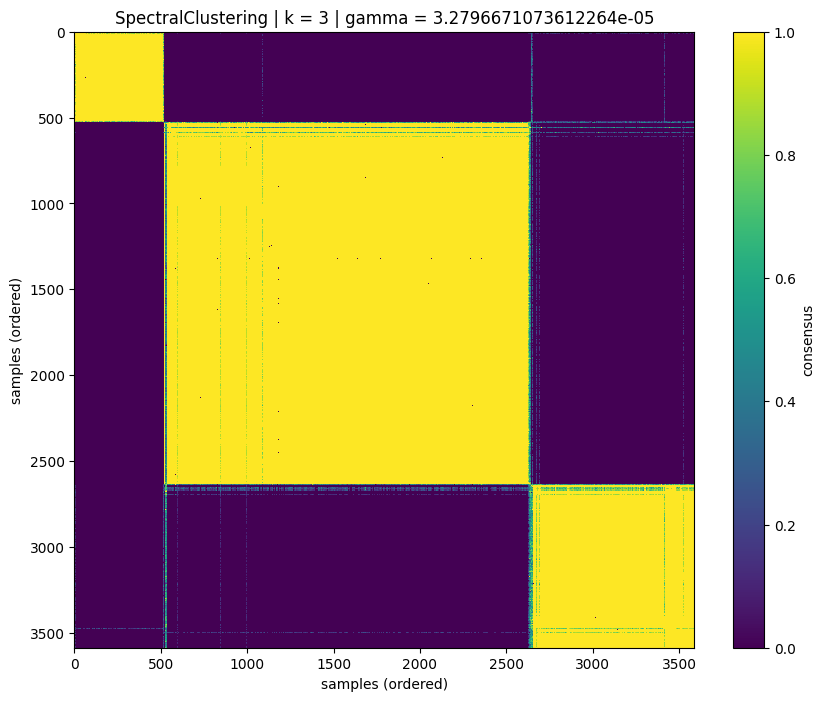

In [23]:
plot_consensus_matrix(validator, measure='overall')

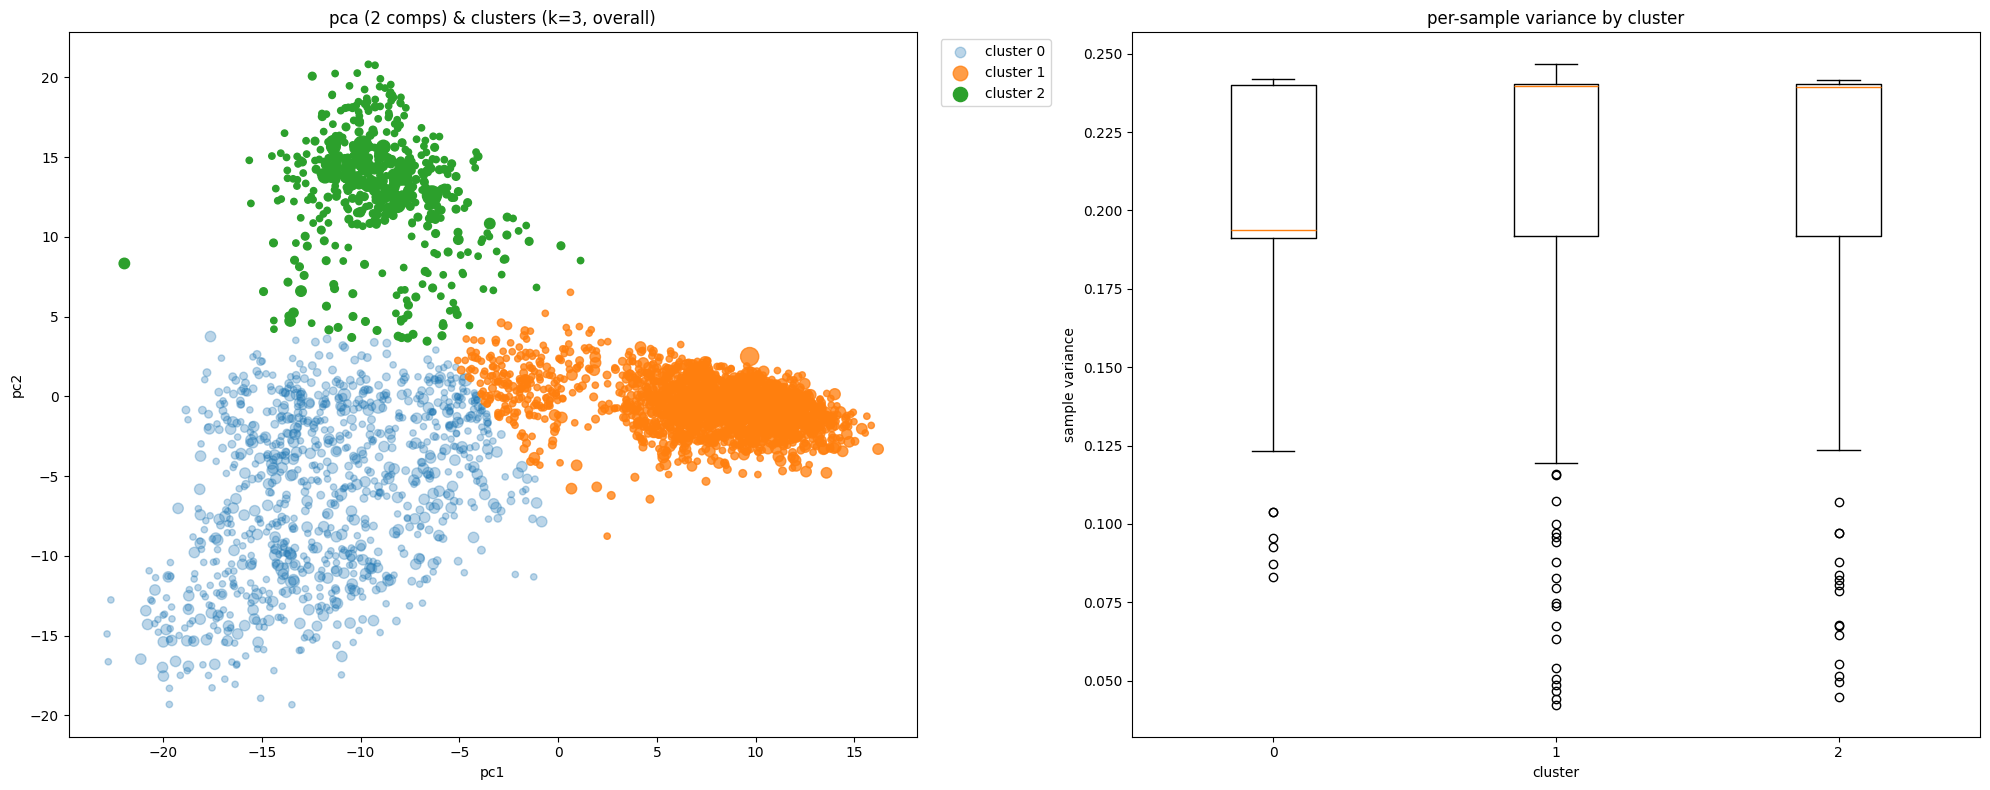

In [45]:
plot_stability_clustering(validator, measure='overall')

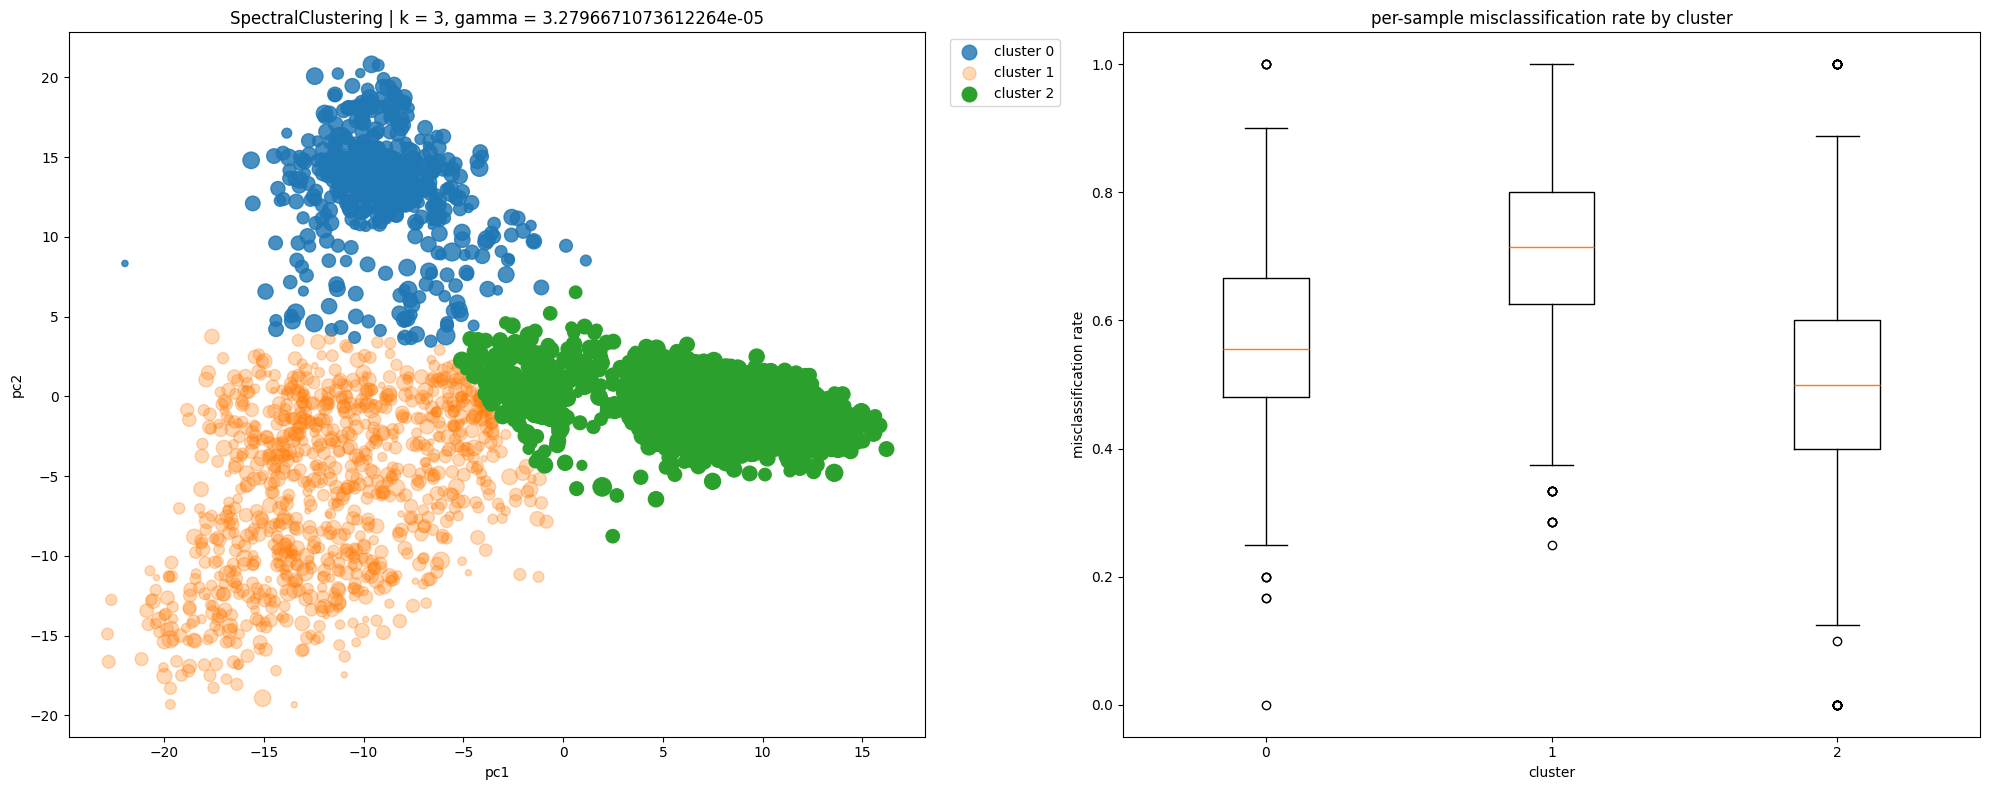

In [46]:
plot_generalizability_clustering(validator, measure='overall')

In [47]:
_, opt_labels = validator.get_optimal_model(return_labels=True)

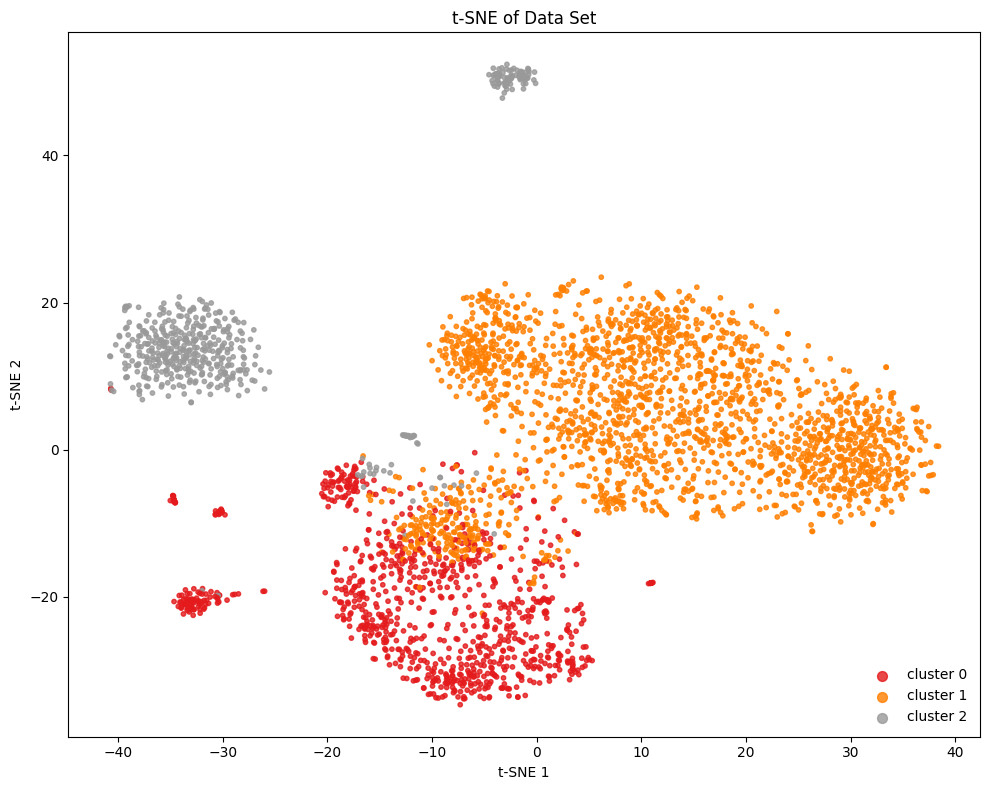

In [48]:
plot_dim_reduced_clustering(X, opt_labels, method='tSNE')